### 5-4. 단순한 계층 구현하기

---

1. 곱셈 계층

In [3]:
# 곱셈 계층

class MulLayer:
    def __init__(self):
        
        self.x = None
        self.y = None


    def forward(self, x, y):

        self.x = x
        self.y = y
        out = x * y

        return out


    def backward(self, dout): # dout는 상류에서 넘어온 미분

        dx = dout * self.y
        dy = dout * self.x

        return dx, dy


apple = 100
apple_num = 2
tax = 1.1

# 계층들
mul_apple_layer = MulLayer()
mul_tax_layer =  MulLayer()

# 순전파
apple_price = mul_apple_layer.forward(apple, apple_num)
price = mul_tax_layer.forward(apple_price, tax)

# 역전파
dprice = 1
dapple_price, dtax = mul_tax_layer.backward(dprice)
dapple, dapple_num = mul_apple_layer.backward(dapple_price)

print(dapple, dapple_num, dtax)



2.2 110.00000000000001 200


2. 덧셈 계층

In [ ]:
# 덧셈 계층

class AddLayer:
    def __init__(self):
        pass

    def forward(self, x, y):
        out = x + y
        return out
    
    def backward(self, dout):
        dx = dout * 1
        dy = dout * 1
        return dx, dy
    
    

3. ReLU 계층

In [ ]:
# ReLU 계층 

def __init__(self):
    self.mask = None

def forward(self, x):
    self.mask = (x <= 0) # x 원소들 중 0보다 작으면 True
    out = x.copy()
    out[self.mask] = 0 # 0보다 작은 값들이 True이기 때문에 그 값들이 0이 된다.

    return out

def backward(self, dout):
    dout[self.mask] = 0
    dx = dout

    return dx

4. Sigmoid 계층


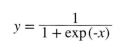

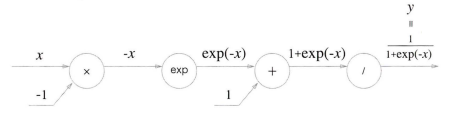

- 위의 식을 따라 아래 계산 그래프처럼 계층을 구성한다.
- 위의 계산 그래프를 단계별로 역전파를 구하면 아래와 같다.

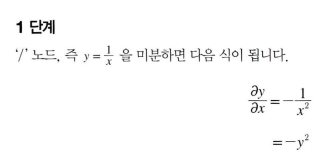


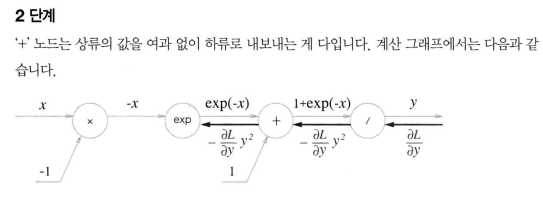


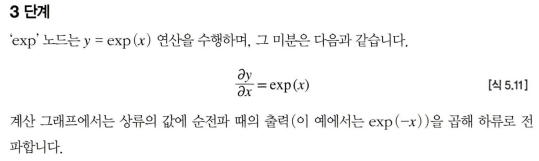


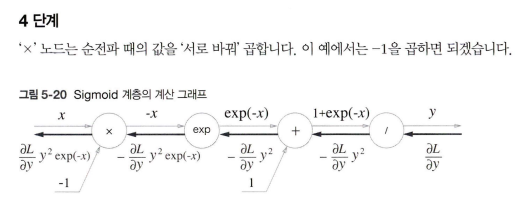

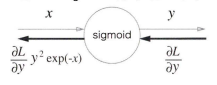

- 역전파 결과 식을 아래와 같이 정리할 수 있다.

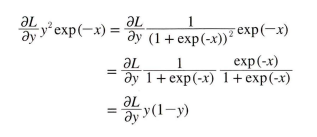

In [5]:
# Sigmoid 계층
import numpy as np

class Sigmoid:
    def __init__(self):
        self.out = None

    def forward(self, x):
        out = 1 / (1 + np.exp(-x))
        self.out = out

        return out
    
    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out

        return dx


5. Affine 계층
###### Affine 변환: 순전파 때 수행하는 행렬의 내적

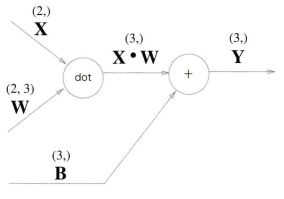

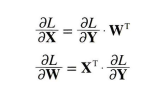

- W^T는 전치행렬을 뜻하는데 전치행렬은 W의 (i,j) 위치의 원소를 (j, i) 위치로 바꾼 것을 의미한다.

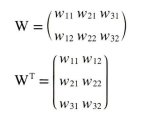

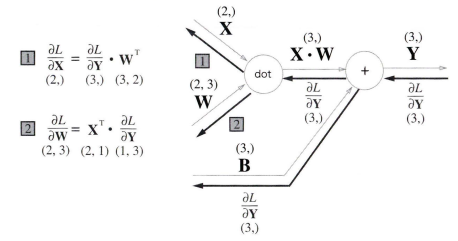

----

#### 배치용 Affine 계층

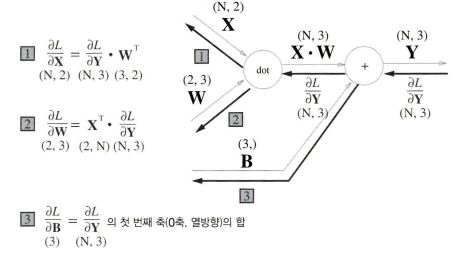

- 이전과 다르게 데이터 N개를 묶어 순전파하는 경우다.
- 편향을 더할 때 편향을 N개의 데이터에 각각 브로드캐스팅 하여 다 더해지기 때문에 역전파에서 편향 덧셈 계층이 이전과 다르게 두 데이터에 대한 미분을 데이터마다 더해서 구한다.

In [8]:
import numpy as np

# 배치용 순전파 편향 더하기 예시

X_dot_W = np.array([[0, 0, 0], [10, 10, 10]])
B = np.array([1, 2, 3])

print(X_dot_W + B)

# 배치용 역전파 편향 더하기 예시

dY = np.array([[1, 2, 3], [4, 5, 6]])
dB = np.sum(dY, axis = 0)
print(dB)

[[ 1  2  3]
 [11 12 13]]
[5 7 9]


In [ ]:
# Affine 계층
import numpy as np

class Affine:
    def __init__(self, W, b):
        self.W = W
        self.b = b
        self.x = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.x = x
        out = np.dot(x, W) + self.b

        return out
    
    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis = 0)

        return dx

6. Softmax-with-Loss 계층

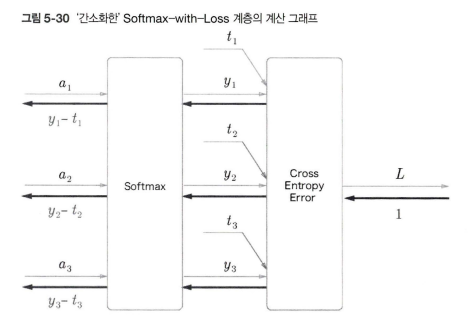

- 간소화한 Softmax-with-Loss 계산 그래프.
- Softmax 활성화함수와 Cross Entropy Error를 함께 사용한다.
- Softmax 출력인 y와 정답 라벨 t의 오차를 역전파로 줘서 이 오차를 계속 줄이는 방식으로 학습한다.

In [10]:
# SoftmaxWithLoss

def softmax(a):
    c = np.max(a)
    exp_a = np.exp(a - c)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    
    return y


def cross_entropy_error(y,t):
    if y.ndim == 1:
        t = t.reshape(1, t.size) # 1차원 벡터를 행렬로 바꿔준다. [1, 2](1차원 벡터), [[1,2]](행렬)
        y = y.reshape(1, y.size)

    batch_size = y.shape[0] # shape[0] = 이미지 수, shape[1] = 특징 수
    return -np.sum(t * np.log(y)) / batch_size


class SoftmaxWithLoss:
    def __init__(self):
        self.loss = None
        self.y = None
        self.t = None

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)
        return self.loss
    
    def backward(self, dout = 1):
        batch_size = self.t.shape[0]
        dx = (self.y - self.t) / batch_size

        return dx
    
